Используя базу "Пассажиры автобуса", подготовьте данные для обучения нейронной сети, классифицирующей изображение на два класса:
- входящий пассажир
- выходящий пассажир

Добейтесь точности работы модели на проверочной выборке не ниже 85%

Ссылка на датасет: https://storage.yandexcloud.net/aiueducation/Content/base/l4/bus.zip

Информацию о загрузке изображений и преобразовании их в numnpy-массивы вы можете найти в Базе знаний:


## Подключение библиотек и загрузка данных

In [15]:
# Работа с массивами
import numpy as np
import os
import zipfile

# Работа с изображениями
from PIL import Image

# Визуализация
import matplotlib.pyplot as plt

# TensorFlow и Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

# Для разделения данных на выборки
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# Отображение графиков прямо в ноутбуке
%matplotlib inline

# Пути к архиву и папке для распаковки
zip_path = "/content/drive/MyDrive/bus.zip"
extract_path = "bus_data"

# Распаковка архива
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Распаковка завершена. Каталог:", os.listdir(extract_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Распаковка завершена. Каталог: ['Входящий', 'Выходящий']


## Предобработка и подготовка данных

In [ ]:
# Определяем классы
classes = ["Входящий", "Выходящий"]

# Списки для хранения изображений и меток
images = []
labels = []

# Преобразуем все изображения в numpy массивы
for label, cls in enumerate(classes):
    cls_folder = os.path.join(extract_path, cls)
    for file_name in os.listdir(cls_folder):
        img_path = os.path.join(cls_folder, file_name)
        try:
            img = Image.open(img_path).convert("L")  # grayscale
            img = img.resize((28,28))                # приведение к размеру 28x28
            images.append(np.array(img))
            labels.append(label)
        except:
            pass

# Преобразуем списки в numpy массивы
X = np.array(images, dtype="float32") / 255.0  # нормализация
y = np.array(labels)  

# Разделение на обучающую, проверочную и тестовую выборки
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42, shuffle=True)

print("Форма X_train:", X_train.shape)
print("Форма y_train:", y_train.shape)
print("Форма X_val:", X_val.shape)
print("Форма y_val:", y_val.shape)
print("Форма X_test:", X_test.shape)
print("Форма y_test:", y_test.shape)

Форма X_train: (7354, 28, 28)
Форма y_train: (7354,)
Форма X_val: (818, 28, 28)
Форма y_val: (818,)
Форма X_test: (909, 28, 28)
Форма y_test: (909,)


## Визуализация

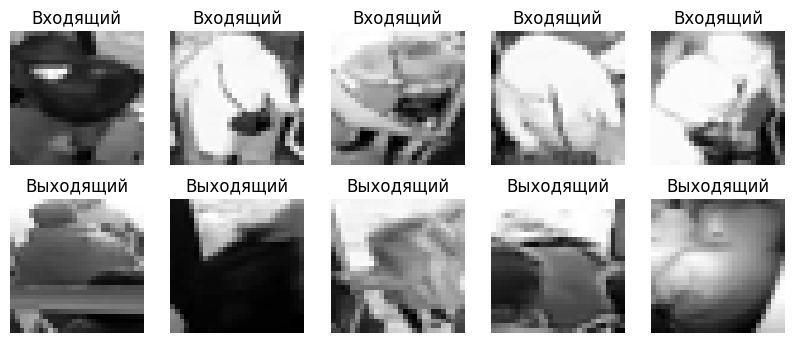

In [17]:
# Показываем по 5 изображений из каждого класса
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[y_train == 0][i], cmap="gray")
    plt.axis("off")
    plt.title("Входящий")

    plt.subplot(2,5,i+6)
    plt.imshow(X_train[y_train == 1][i], cmap="gray")
    plt.axis("off")
    plt.title("Выходящий")
plt.show()

## Создание модели

In [18]:
model = Sequential()
model.add(Flatten(input_shape=(28,28)))   # преобразуем 2D в 1D
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,866 (425.26 KB)

 Trainable params: 108,866 (425.26 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

In [19]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7101 - loss: 0.5908 - val_accuracy: 0.7262 - val_loss: 0.5528
Epoch 2/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7306 - loss: 0.5539 - val_accuracy: 0.7506 - val_loss: 0.5515
Epoch 3/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7480 - loss: 0.5350 - val_accuracy: 0.7567 - val_loss: 0.5027
Epoch 4/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7503 - loss: 0.5198 - val_accuracy: 0.7641 - val_loss: 0.4890
Epoch 5/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7664 - loss: 0.4959 - val_accuracy: 0.7738 - val_loss: 0.4685
Epoch 6/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7702 - loss: 0.4803 - val_accuracy: 0.7922 - val_loss: 0.4419
Epoch 7/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7800 - loss: 0.4705 - val_accuracy: 0.7971 - val_loss: 0.4360
Epoch 8/30
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7925 - loss: 0.4479 - val_accuracy: 0

## Визуализация точности и ошибки

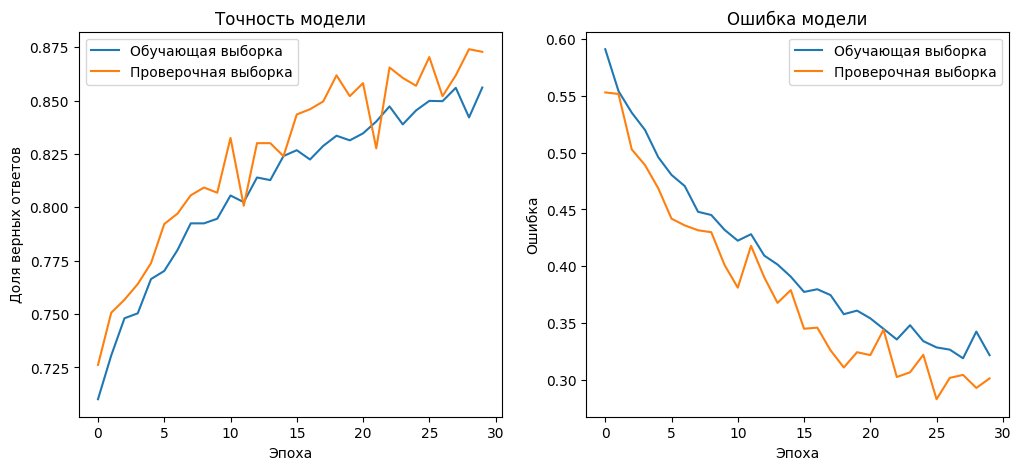

In [20]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Обучающая выборка")
plt.plot(history.history['val_accuracy'], label="Проверочная выборка")
plt.xlabel("Эпоха")
plt.ylabel("Доля верных ответов")
plt.title("Точность модели")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Обучающая выборка")
plt.plot(history.history['val_loss'], label="Проверочная выборка")
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.title("Ошибка модели")
plt.legend()

plt.show()

## Оценка модели на тестовой выборке

In [21]:
scores = model.evaluate(X_test, y_test, verbose=0)
print("Доля верных ответов на тестовых данных: {:7.4%}".format(scores[1]))

Доля верных ответов на тестовых данных: 87.7888%
